# Old 2D ILT on New 3C Non-Gaussian Forward Model (16x16)

Goal: feed signals generated by the new 3C non-Gaussian model into the old 2D ILT pipeline and test whether we observe:
- peak broadening
- sphere compartment interpreted as multiple apparent components
- DEI bias
- exchange-peak intensity instability
- worsening error with larger $R_s$ and lower SNR


In [13]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent]
repo_root = None
for c in candidate_roots:
    if (c / 'dexsy_core').exists():
        repo_root = c
        break
if repo_root is None:
    raise RuntimeError('Could not locate repo root containing dexsy_core.')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from dexsy_core import (
    ForwardModel3CNonGaussian,
    create_forward_model,
    compute_dei,
)

np.set_printoptions(precision=4, suppress=True)
print('Repo root:', repo_root)


Repo root: /Users/lingfzuo/Desktop/IC/FYP/FYP


In [14]:
# New physics model (signal generator) and old ILT model (inverter), both 16x16
fm_new = ForwardModel3CNonGaussian(n_b=16, n_restrict_terms=500)
fm_old = create_forward_model(profile=16)  # legacy Gaussian-kernel ILT forward/inverse

print('new n_b =', fm_new.n_b)
print('old n_b/n_d =', fm_old.n_b, fm_old.n_d)


new n_b = 16
old n_b/n_d = 16 16


In [15]:
def run_old_ilt(signal_16x16, alpha=0.02, post_sharpen=True, sharpen_sigma=0.9, sharpen_strength=0.30):
    f_est = fm_old.compute_ilt_nnls(
        signal_16x16,
        alpha=alpha,
        post_sharpen=post_sharpen,
        sharpen_sigma=sharpen_sigma,
        sharpen_strength=sharpen_strength,
        renorm=True,
    )
    return f_est

def diag_profile_metrics(f):
    d = np.diag(f).astype(np.float64)
    s = d.sum() + 1e-12
    p = d / s
    idx = np.arange(len(d), dtype=np.float64)
    mu = float((idx * p).sum())
    var = float(((idx - mu) ** 2 * p).sum())
    std = float(np.sqrt(max(var, 0.0)))

    thr = 0.20 * float(d.max() + 1e-12)
    n_local = 0
    for i in range(1, len(d)-1):
        if d[i] >= d[i-1] and d[i] >= d[i+1] and d[i] >= thr:
            n_local += 1
    if len(d) >= 2:
        if d[0] >= d[1] and d[0] >= thr:
            n_local += 1
        if d[-1] >= d[-2] and d[-1] >= thr:
            n_local += 1

    return {
        'diag_std': std,
        'diag_local_peaks_above_20pct': int(n_local),
    }

def reprojection_rmse(signal_ref, f_est):
    signal_fit = fm_old.compute_signal(f_est, noise_sigma=0.0, normalize=True, noise_model=None)
    rmse = float(np.sqrt(np.mean((signal_fit - signal_ref) ** 2)))
    return rmse, signal_fit

def estimate_effective_diffusivity_from_kernel(b, k, n_points=6):
    mask = (b > 0) & (k > 0)
    x = np.asarray(b[mask], dtype=np.float64)
    y = -np.log(np.asarray(k[mask], dtype=np.float64))
    if x.size == 0:
        return 1e-12
    n = min(max(3, n_points), x.size)
    x = x[:n]
    y = y[:n]
    A = np.vstack([x, np.ones_like(x)]).T
    slope, intercept = np.linalg.lstsq(A, y, rcond=None)[0]
    return float(max(slope, 1e-12))

def nearest_d_index(d_value, d_grid):
    return int(np.argmin(np.abs(np.log(d_grid) - np.log(max(d_value, 1e-12)))))

def pathway_local_masses(f_est, idx_map, radius=1):
    f = np.asarray(f_est, dtype=np.float64)
    n = f.shape[0]
    comps = ['E', 'T', 'S']
    masses = {}
    union_mask = np.zeros_like(f, dtype=bool)
    for ci in comps:
        for cj in comps:
            i = idx_map[ci]
            j = idx_map[cj]
            i0, i1 = max(0, i-radius), min(n, i+radius+1)
            j0, j1 = max(0, j-radius), min(n, j+radius+1)
            m = np.zeros_like(f, dtype=bool)
            m[i0:i1, j0:j1] = True
            union_mask |= m
            masses[ci+cj] = float(f[m].sum())
    local_total = float(sum(masses.values())) + 1e-12
    masses_norm = {k: float(v / local_total) for k, v in masses.items()}
    in_union = float(f[union_mask].sum())
    return masses, masses_norm, in_union

def compare_weight_vs_ilt_masses(details, f_est, D_E, D_I, l_T, R_S, radius=1):
    # Build apparent compartment locations on old D-grid from current kernels.
    kern = fm_new.compartment_kernels(
        g=fm_new.G1,
        extracellular_diffusivity=D_E,
        intracellular_diffusivity=D_I,
        axon_restricted_length=l_T,
        sphere_radius=R_S,
    )
    d_eff = {
        'E': estimate_effective_diffusivity_from_kernel(fm_new.b1, kern['E']),
        'T': estimate_effective_diffusivity_from_kernel(fm_new.b1, kern['T']),
        'S': estimate_effective_diffusivity_from_kernel(fm_new.b1, kern['S']),
    }
    idx_map = {k: nearest_d_index(v, fm_old.D1) for k, v in d_eff.items()}

    m_raw, m_norm, in_union = pathway_local_masses(f_est, idx_map, radius=radius)
    w_true = details['pathway_weights']

    diag_keys = ['EE', 'TT', 'SS']
    true_diag = float(sum(w_true[k] for k in diag_keys))
    true_off = float(sum(w_true[k] for k in w_true if k not in diag_keys))
    ilt_diag = float(sum(m_norm[k] for k in diag_keys))
    ilt_off = float(sum(m_norm[k] for k in m_norm if k not in diag_keys))

    return {
        'd_eff': d_eff,
        'idx_map': idx_map,
        'w_true': dict(w_true),
        'ilt_masses_raw': m_raw,
        'ilt_masses_norm': m_norm,
        'ilt_union_mass': float(in_union),
        'diag_off_true': {'diag': true_diag, 'off': true_off},
        'diag_off_ilt': {'diag': ilt_diag, 'off': ilt_off},
    }

def compute_gaussian_3c_signal(phi, q, mixing_time, dE, dT, dS, normalize=True):
    w, p, phi_n = fm_new.compute_weight_matrix(phi=phi, q=q, mixing_time=mixing_time)
    b1 = fm_new.b1
    b2 = fm_new.b2
    k1 = np.stack([
        np.exp(-b1 * dE),
        np.exp(-b1 * dT),
        np.exp(-b1 * dS),
    ], axis=1)
    k2 = np.stack([
        np.exp(-b2 * dE),
        np.exp(-b2 * dT),
        np.exp(-b2 * dS),
    ], axis=1)
    s = k1 @ w @ k2.T
    s = np.clip(s, 0.0, None)
    if normalize:
        s0 = max(float(s[0, 0]), 1e-12)
        s = s / s0
    details = {
        'weight_matrix': w,
        'transition_matrix': p,
        'phi': phi_n,
        'pathway_weights': {
            nm: float(w[i,j])
            for i,n1 in enumerate(['E','T','S'])
            for j,n2 in enumerate(['E','T','S'])
            for nm in [n1+n2]
        },
    }
    return s.astype(np.float64), details

def run_case(phi, q, tm, D_E, D_I, l_T, R_S, noise_sigma=0.0, seed=0, alpha=0.02, post_sharpen=True):
    signal_clean, details = fm_new.compute_signal(
        phi=phi, q=q, mixing_time=tm,
        extracellular_diffusivity=D_E,
        intracellular_diffusivity=D_I,
        axon_restricted_length=l_T,
        sphere_radius=R_S,
        normalize=True,
    )
    if noise_sigma > 0:
        rng = np.random.default_rng(seed)
        signal_in = fm_new.add_rician_noise(signal_clean, noise_sigma=noise_sigma, normalize=True, rng=rng)
    else:
        signal_in = signal_clean.copy()

    f_est = run_old_ilt(signal_in, alpha=alpha, post_sharpen=post_sharpen)
    dei_true = fm_new.compute_dei_from_weight_matrix(details['weight_matrix'])
    dei_est = compute_dei(f_est, diagonal_band_width=2)
    dei_bias = float(dei_est - dei_true)
    rmse, signal_fit = reprojection_rmse(signal_clean, f_est)
    diag_m = diag_profile_metrics(f_est)

    out = {
        'signal_clean': signal_clean,
        'signal_in': signal_in,
        'signal_fit': signal_fit,
        'f_est': f_est,
        'details': details,
        'dei_true': float(dei_true),
        'dei_est': float(dei_est),
        'dei_bias': dei_bias,
        'rmse': rmse,
        **diag_m,
        'alpha': float(alpha),
        'post_sharpen': bool(post_sharpen),
    }
    return out


## A) Sphere-only no-exchange: broadening + multi-component behavior


In [16]:
phi_sphere_only = np.array([0.0, 0.0, 1.0], dtype=np.float64)
q_zero = np.zeros((3, 3), dtype=np.float64)
tm = 0.08
D_E = 1.7e-9
D_I = 0.7e-9
l_T = 1.0e-6
Rs_list = [1.0e-6, 2.0e-6, 4.0e-6, 6.0e-6]

rows = []
cases = []
for Rs in Rs_list:
    c = run_case(phi_sphere_only, q_zero, tm, D_E, D_I, l_T, Rs, noise_sigma=0.0)
    cases.append((Rs, c))
    rows.append([Rs*1e6, c['diag_std'], c['diag_local_peaks_above_20pct'], c['rmse']])

print('R_s(um) | diag_std | n_local_peaks(>20% max) | reproj_rmse')
for r in rows:
    print(f'{r[0]:7.2f} | {r[1]:8.3f} | {int(r[2]):23d} | {r[3]:.5f}')


R_s(um) | diag_std | n_local_peaks(>20% max) | reproj_rmse
   1.00 |    0.000 |                       1 | 0.00614
   2.00 |    0.000 |                       1 | 0.00497
   4.00 |    0.000 |                       1 | 0.01737
   6.00 |    0.484 |                       1 | 0.00992


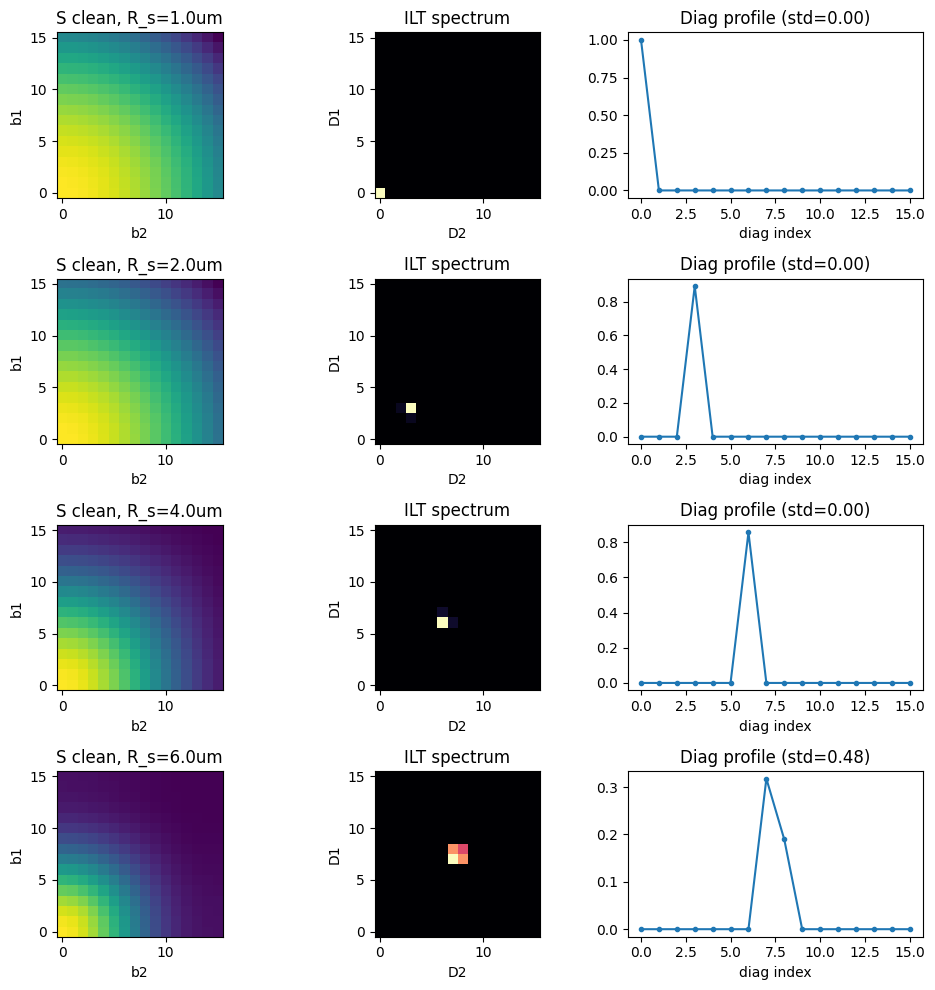

In [17]:
fig, axes = plt.subplots(len(cases), 3, figsize=(9.8, 2.5*len(cases)))
if len(cases) == 1:
    axes = np.array([axes])

for i, (Rs, c) in enumerate(cases):
    axes[i,0].imshow(c['signal_clean'], origin='lower', cmap='viridis', interpolation='nearest')
    axes[i,0].set_title(f'S clean, R_s={Rs*1e6:.1f}um')

    axes[i,1].imshow(c['f_est'], origin='lower', cmap='magma', interpolation='nearest')
    axes[i,1].set_title('ILT spectrum')

    d = np.diag(c['f_est'])
    axes[i,2].plot(d, '-o', ms=3)
    axes[i,2].set_title('Diag profile (std={:.2f})'.format(c['diag_std']))
    axes[i,2].set_xlabel('diag index')

for i in range(len(cases)):
    axes[i,0].set_xlabel('b2'); axes[i,0].set_ylabel('b1')
    axes[i,1].set_xlabel('D2'); axes[i,1].set_ylabel('D1')

plt.tight_layout()
plt.show()


## B) DEI bias + exchange intensity instability across noise realizations


In [18]:
phi = np.array([0.45, 0.35, 0.20], dtype=np.float64)
q = fm_new.build_generator(k_et=3.0, k_te=2.0, k_es=1.5, k_se=1.2, k_ts=0.0, k_st=0.0)
tm = 0.08
D_E = 1.7e-9
D_I = 0.7e-9
l_T = 1.0e-6
R_S = 4.0e-6
noise_sigma = 0.01

trials = 40
dei_true_list = []
dei_est_list = []
offdiag_mass_list = []

for t in range(trials):
    c = run_case(phi, q, tm, D_E, D_I, l_T, R_S, noise_sigma=noise_sigma, seed=1000+t)
    dei_true_list.append(c['dei_true'])
    dei_est_list.append(c['dei_est'])
    n = c['f_est'].shape[0]
    ii, jj = np.indices((n,n))
    off = c['f_est'][np.abs(ii-jj) > 2].sum()
    offdiag_mass_list.append(float(off))

dei_true = float(np.mean(dei_true_list))
dei_est_mean = float(np.mean(dei_est_list))
dei_est_std = float(np.std(dei_est_list))
dei_bias = dei_est_mean - dei_true

print(f'True DEI: {dei_true:.4f}')
print(f'Estimated DEI mean±std: {dei_est_mean:.4f} ± {dei_est_std:.4f}')
print(f'DEI bias (est-true): {dei_bias:+.4f}')
print(f'Off-diagonal mass std (exchange-peak instability proxy): {np.std(offdiag_mass_list):.4f}')


True DEI: 0.2365
Estimated DEI mean±std: 0.2337 ± 0.0387
DEI bias (est-true): -0.0028
Off-diagonal mass std (exchange-peak instability proxy): 0.0250


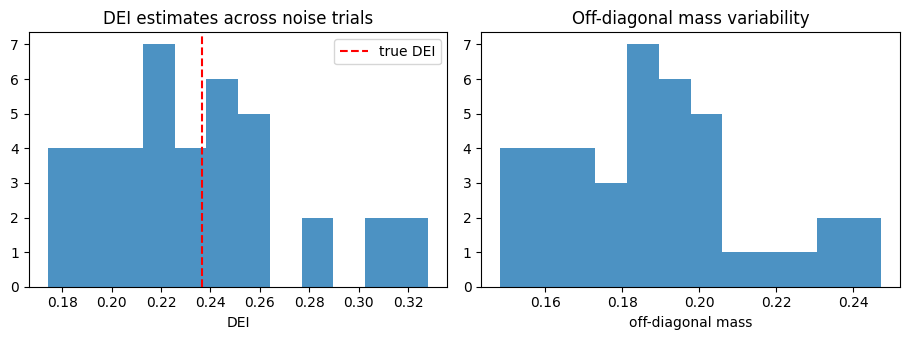

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.5))
axes[0].hist(dei_est_list, bins=12, alpha=0.8)
axes[0].axvline(dei_true, color='r', linestyle='--', label='true DEI')
axes[0].set_title('DEI estimates across noise trials')
axes[0].set_xlabel('DEI')
axes[0].legend()

axes[1].hist(offdiag_mass_list, bins=12, alpha=0.8)
axes[1].set_title('Off-diagonal mass variability')
axes[1].set_xlabel('off-diagonal mass')

plt.tight_layout()
plt.show()


## C) Error trend vs sphere radius $R_s$ and SNR


In [20]:
phi = np.array([0.45, 0.35, 0.20], dtype=np.float64)
q = fm_new.build_generator(k_et=3.0, k_te=2.0, k_es=1.5, k_se=1.2, k_ts=0.0, k_st=0.0)
tm = 0.08
D_E = 1.7e-9
D_I = 0.7e-9
l_T = 1.0e-6

Rs_um = np.array([1.0, 2.0, 4.0, 6.0], dtype=np.float64)
SNRs = np.array([20, 40, 80, 120], dtype=np.float64)
repeats = 12

abs_dei_bias_map = np.zeros((len(Rs_um), len(SNRs)), dtype=np.float64)
rmse_map = np.zeros_like(abs_dei_bias_map)

for i, rs in enumerate(Rs_um):
    for j, snr in enumerate(SNRs):
        sigma = 1.0 / snr
        dei_biases = []
        rmses = []
        for r in range(repeats):
            c = run_case(
                phi, q, tm, D_E, D_I, l_T, rs*1e-6,
                noise_sigma=sigma,
                seed=50000 + 100*i + 10*j + r,
            )
            dei_biases.append(abs(c['dei_bias']))
            rmses.append(c['rmse'])
        abs_dei_bias_map[i, j] = float(np.mean(dei_biases))
        rmse_map[i, j] = float(np.mean(rmses))

print('Mean |DEI bias| map:', abs_dei_bias_map)
print('Mean reprojection RMSE map:', rmse_map)


Mean |DEI bias| map: [[0.1034 0.0343 0.0171 0.0068]
 [0.094  0.1293 0.0464 0.0269]
 [0.1059 0.067  0.0319 0.0217]
 [0.1885 0.0834 0.0544 0.0347]]
Mean reprojection RMSE map: [[0.0237 0.0131 0.011  0.0069]
 [0.0252 0.0138 0.018  0.0195]
 [0.0223 0.016  0.0139 0.0135]
 [0.0186 0.012  0.0126 0.0116]]


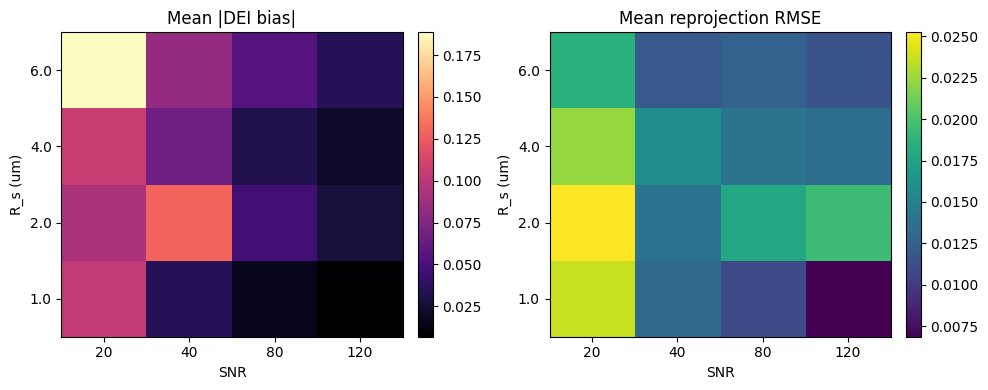

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.0))

im0 = axes[0].imshow(abs_dei_bias_map, origin='lower', cmap='magma', aspect='auto')
axes[0].set_title('Mean |DEI bias|')
axes[0].set_xticks(np.arange(len(SNRs)))
axes[0].set_xticklabels([str(int(x)) for x in SNRs])
axes[0].set_yticks(np.arange(len(Rs_um)))
axes[0].set_yticklabels([f'{x:.1f}' for x in Rs_um])
axes[0].set_xlabel('SNR')
axes[0].set_ylabel('R_s (um)')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(rmse_map, origin='lower', cmap='viridis', aspect='auto')
axes[1].set_title('Mean reprojection RMSE')
axes[1].set_xticks(np.arange(len(SNRs)))
axes[1].set_xticklabels([str(int(x)) for x in SNRs])
axes[1].set_yticks(np.arange(len(Rs_um)))
axes[1].set_yticklabels([f'{x:.1f}' for x in Rs_um])
axes[1].set_xlabel('SNR')
axes[1].set_ylabel('R_s (um)')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## D) Alpha Sweep + Post-Sharpen Sweep

Check that instability is not caused by one specific `alpha` choice.


In [22]:
phi = np.array([0.45, 0.35, 0.20], dtype=np.float64)
q = fm_new.build_generator(k_et=3.0, k_te=2.0, k_es=1.5, k_se=1.2, k_ts=0.0, k_st=0.0)
tm = 0.08
D_E = 1.7e-9
D_I = 0.7e-9
l_T = 1.0e-6
R_S = 4.0e-6
noise_sigma = 0.01

alphas = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
post_opts = [False, True]
trials = 16

sweep_rows = []
for post in post_opts:
    for alpha in alphas:
        dei_est = []
        rmse_vals = []
        for t in range(trials):
            c = run_case(
                phi, q, tm, D_E, D_I, l_T, R_S,
                noise_sigma=noise_sigma, seed=22000 + 1000*int(post) + int(alpha*1000) + t,
                alpha=alpha, post_sharpen=post,
            )
            dei_est.append(c['dei_est'])
            rmse_vals.append(c['rmse'])
        sweep_rows.append({
            'alpha': alpha,
            'post_sharpen': post,
            'dei_mean': float(np.mean(dei_est)),
            'dei_std': float(np.std(dei_est)),
            'rmse_mean': float(np.mean(rmse_vals)),
            'rmse_std': float(np.std(rmse_vals)),
        })

print('alpha | post_sharpen | DEI mean±std | RMSE mean±std')
for r in sweep_rows:
    print(f"{r['alpha']:<6} | {str(r['post_sharpen']):<12} | {r['dei_mean']:.4f} ± {r['dei_std']:.4f} | {r['rmse_mean']:.5f} ± {r['rmse_std']:.5f}")


alpha | post_sharpen | DEI mean±std | RMSE mean±std
0.001  | False        | 0.2330 ± 0.0364 | 0.00360 ± 0.00142
0.005  | False        | 0.2398 ± 0.0396 | 0.00396 ± 0.00168
0.01   | False        | 0.2223 ± 0.0291 | 0.00418 ± 0.00150
0.02   | False        | 0.2273 ± 0.0443 | 0.00396 ± 0.00151
0.05   | False        | 0.2311 ± 0.0225 | 0.00341 ± 0.00103
0.1    | False        | 0.2251 ± 0.0340 | 0.00386 ± 0.00091
0.001  | True         | 0.2345 ± 0.0384 | 0.01208 ± 0.00394
0.005  | True         | 0.2388 ± 0.0355 | 0.01156 ± 0.00434
0.01   | True         | 0.2288 ± 0.0349 | 0.01161 ± 0.00458
0.02   | True         | 0.2266 ± 0.0311 | 0.01214 ± 0.00510
0.05   | True         | 0.2272 ± 0.0215 | 0.01538 ± 0.00344
0.1    | True         | 0.2227 ± 0.0230 | 0.01481 ± 0.00212


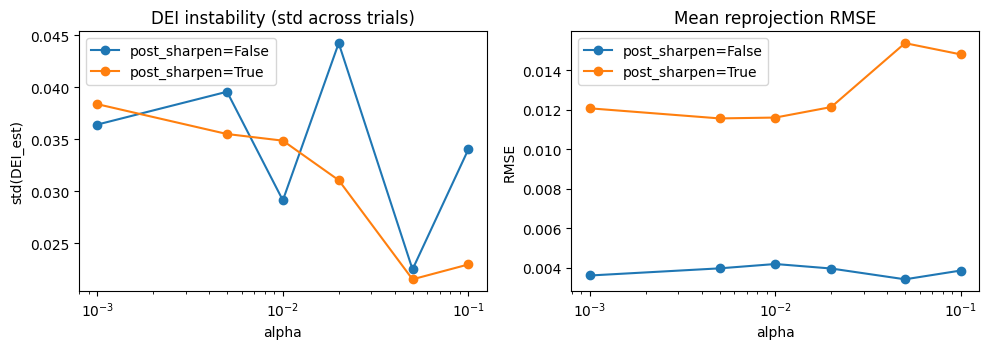

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for post in [False, True]:
    rr = [r for r in sweep_rows if r['post_sharpen'] == post]
    x = [r['alpha'] for r in rr]
    y = [r['dei_std'] for r in rr]
    y2 = [r['rmse_mean'] for r in rr]
    lbl = f'post_sharpen={post}'
    axes[0].plot(x, y, '-o', label=lbl)
    axes[1].plot(x, y2, '-o', label=lbl)
axes[0].set_xscale('log')
axes[0].set_title('DEI instability (std across trials)')
axes[0].set_xlabel('alpha')
axes[0].set_ylabel('std(DEI_est)')
axes[0].legend()

axes[1].set_xscale('log')
axes[1].set_title('Mean reprojection RMSE')
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('RMSE')
axes[1].legend()

plt.tight_layout()
plt.show()


## E) Ground-Truth $W$ vs ILT-Derived Mass (9 pathways + diag/off)


In [24]:
phi = np.array([0.45, 0.35, 0.20], dtype=np.float64)
q = fm_new.build_generator(k_et=3.0, k_te=2.0, k_es=1.5, k_se=1.2, k_ts=0.0, k_st=0.0)
tm = 0.08
D_E = 1.7e-9
D_I = 0.7e-9
l_T = 1.0e-6
R_S = 4.0e-6

c = run_case(phi, q, tm, D_E, D_I, l_T, R_S, noise_sigma=0.01, seed=123, alpha=0.02, post_sharpen=True)
cmp_res = compare_weight_vs_ilt_masses(c['details'], c['f_est'], D_E, D_I, l_T, R_S, radius=1)

print('Effective compartment diffusivities used for region mapping:')
print(cmp_res['d_eff'])
print('Mapped indices on 16x16 D-grid:')
print(cmp_res['idx_map'])
print('Union mass captured by local windows:', cmp_res['ilt_union_mass'])

print('diag/off true :', cmp_res['diag_off_true'])
print('diag/off ILT  :', cmp_res['diag_off_ilt'])

keys = ['EE','ET','ES','TE','TT','TS','SE','ST','SS']
print('path | W_true | ILT_mass_norm | abs_err')
for k in keys:
    wt = cmp_res['w_true'][k]
    mi = cmp_res['ilt_masses_norm'][k]
    print(f'{k}  | {wt:.4f} | {mi:.4f} | {abs(wt-mi):.4f}')


Effective compartment diffusivities used for region mapping:
{'E': 1.7e-09, 'T': 9.277466584547221e-12, 'S': 1.508342943104108e-10}
Mapped indices on 16x16 D-grid:
{'E': 11, 'T': 0, 'S': 6}
Union mass captured by local windows: 0.9616315960102048
diag/off true : {'diag': 0.8087116218433781, 'off': 0.19128837815662192}
diag/off ILT  : {'diag': 0.82560234898184, 'off': 0.17439765101712013}
path | W_true | ILT_mass_norm | abs_err
EE  | 0.3224 | 0.3254 | 0.0029
ET  | 0.0841 | 0.0528 | 0.0313
ES  | 0.0435 | 0.0911 | 0.0476
TE  | 0.0436 | 0.0305 | 0.0131
TT  | 0.3036 | 0.3021 | 0.0016
TS  | 0.0028 | 0.0000 | 0.0028
SE  | 0.0155 | 0.0000 | 0.0155
ST  | 0.0019 | 0.0000 | 0.0019
SS  | 0.1827 | 0.1982 | 0.0155


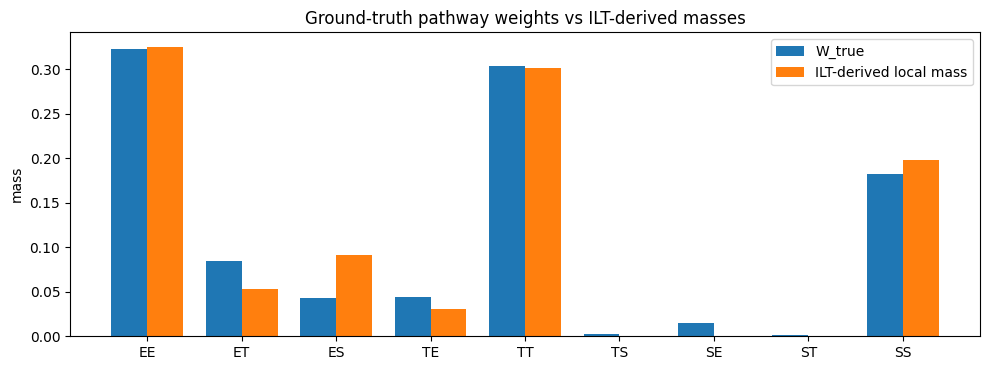

In [25]:
keys = ['EE','ET','ES','TE','TT','TS','SE','ST','SS']
w_true = np.array([cmp_res['w_true'][k] for k in keys], dtype=np.float64)
w_ilt = np.array([cmp_res['ilt_masses_norm'][k] for k in keys], dtype=np.float64)

x = np.arange(len(keys))
width = 0.38
plt.figure(figsize=(10,3.8))
plt.bar(x - width/2, w_true, width=width, label='W_true')
plt.bar(x + width/2, w_ilt, width=width, label='ILT-derived local mass')
plt.xticks(x, keys)
plt.ylabel('mass')
plt.title('Ground-truth pathway weights vs ILT-derived masses')
plt.legend()
plt.tight_layout()
plt.show()


## F) Gaussian 3C Baseline (same $W,\phi,k$, different kernels)


In [26]:
phi = np.array([0.45, 0.35, 0.20], dtype=np.float64)
q = fm_new.build_generator(k_et=3.0, k_te=2.0, k_es=1.5, k_se=1.2, k_ts=0.0, k_st=0.0)
tm = 0.08
D_E = 1.7e-9
D_I = 0.7e-9
l_T = 1.0e-6
R_S = 4.0e-6
noise_sigma = 0.01

# Non-Gaussian signal
sig_ng, det_ng = fm_new.compute_signal(
    phi=phi, q=q, mixing_time=tm,
    extracellular_diffusivity=D_E, intracellular_diffusivity=D_I,
    axon_restricted_length=l_T, sphere_radius=R_S, normalize=True
)

# Match Gaussian compartment diffusivities to low-b effective slopes of non-Gaussian kernels
kern = fm_new.compartment_kernels(fm_new.G1, D_E, D_I, l_T, R_S)
dE_eff = estimate_effective_diffusivity_from_kernel(fm_new.b1, kern['E'])
dT_eff = estimate_effective_diffusivity_from_kernel(fm_new.b1, kern['T'])
dS_eff = estimate_effective_diffusivity_from_kernel(fm_new.b1, kern['S'])

sig_g, det_g = compute_gaussian_3c_signal(
    phi=phi, q=q, mixing_time=tm, dE=dE_eff, dT=dT_eff, dS=dS_eff, normalize=True
)

# Add same-noise-level realizations
rng = np.random.default_rng(42)
sig_ng_n = fm_new.add_rician_noise(sig_ng, noise_sigma=noise_sigma, normalize=True, rng=rng)
sig_g_n = fm_new.add_rician_noise(sig_g, noise_sigma=noise_sigma, normalize=True, rng=np.random.default_rng(42))

f_ng = run_old_ilt(sig_ng_n, alpha=0.02, post_sharpen=True)
f_g = run_old_ilt(sig_g_n, alpha=0.02, post_sharpen=True)

rmse_ng, fit_ng = reprojection_rmse(sig_ng, f_ng)
rmse_g, fit_g = reprojection_rmse(sig_g, f_g)
dei_true_ng = fm_new.compute_dei_from_weight_matrix(det_ng['weight_matrix'])
dei_true_g = fm_new.compute_dei_from_weight_matrix(det_g['weight_matrix'])
dei_est_ng = compute_dei(f_ng, diagonal_band_width=2)
dei_est_g = compute_dei(f_g, diagonal_band_width=2)

print('Matched effective diffusivities (for Gaussian baseline):')
print({'D_E_eff': dE_eff, 'D_T_eff': dT_eff, 'D_S_eff': dS_eff})
print('---')
print(f'Gaussian 3C ILT error (RMSE): {rmse_g:.5f}, DEI bias: {(dei_est_g-dei_true_g):+.4f}')
print(f'Non-Gaussian 3C ILT error (RMSE): {rmse_ng:.5f}, DEI bias: {(dei_est_ng-dei_true_ng):+.4f}')


Matched effective diffusivities (for Gaussian baseline):
{'D_E_eff': 1.7e-09, 'D_T_eff': 9.277466584547221e-12, 'D_S_eff': 1.508342943104108e-10}
---
Gaussian 3C ILT error (RMSE): 0.01265, DEI bias: -0.0063
Non-Gaussian 3C ILT error (RMSE): 0.01450, DEI bias: -0.0207


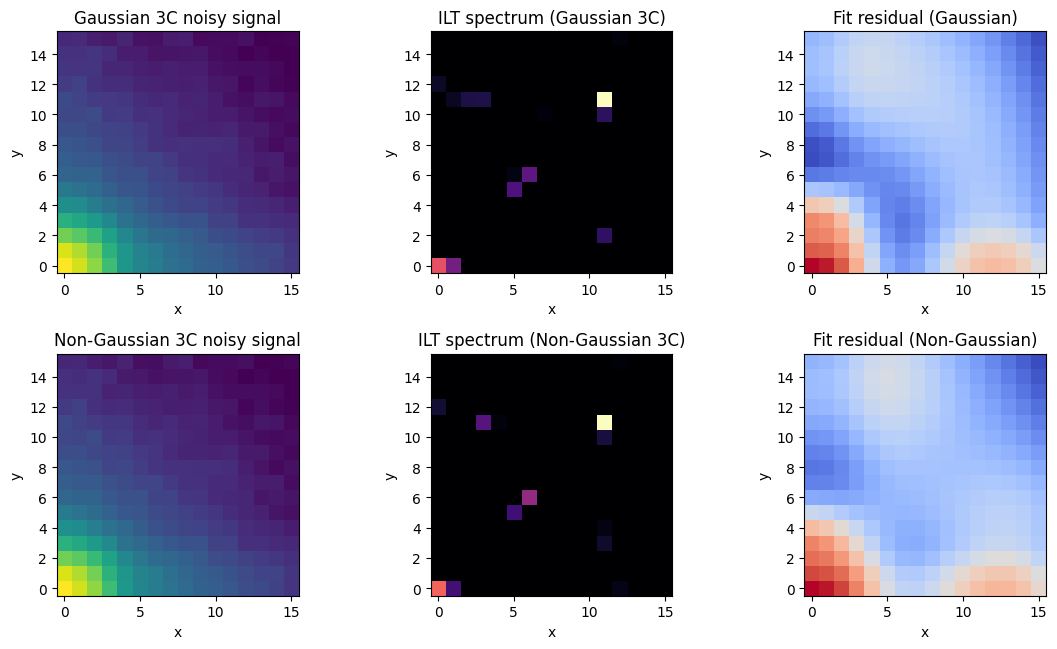

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(11.5, 6.6))

axes[0,0].imshow(sig_g_n, origin='lower', cmap='viridis', interpolation='nearest')
axes[0,0].set_title('Gaussian 3C noisy signal')
axes[1,0].imshow(sig_ng_n, origin='lower', cmap='viridis', interpolation='nearest')
axes[1,0].set_title('Non-Gaussian 3C noisy signal')

axes[0,1].imshow(f_g, origin='lower', cmap='magma', interpolation='nearest')
axes[0,1].set_title('ILT spectrum (Gaussian 3C)')
axes[1,1].imshow(f_ng, origin='lower', cmap='magma', interpolation='nearest')
axes[1,1].set_title('ILT spectrum (Non-Gaussian 3C)')

axes[0,2].imshow(fit_g - sig_g, origin='lower', cmap='coolwarm', interpolation='nearest')
axes[0,2].set_title('Fit residual (Gaussian)')
axes[1,2].imshow(fit_ng - sig_ng, origin='lower', cmap='coolwarm', interpolation='nearest')
axes[1,2].set_title('Fit residual (Non-Gaussian)')

for i in range(2):
    for j in range(3):
        axes[i,j].set_xlabel('x')
        axes[i,j].set_ylabel('y')

plt.tight_layout()
plt.show()


## Quick interpretation guide

- If `diag_std` is large and local peaks > 1 for sphere-only/no-exchange, ILT is broadening and splitting sphere behavior into multiple apparent components.
- Non-zero mean `DEI bias` indicates systematic DEI distortion.
- Large std in off-diagonal mass across identical-physics noise trials indicates exchange-intensity instability.
- Upward trends in `|DEI bias|` and RMSE with larger $R_s$ or lower SNR indicate parameter-dependent degradation.
